# The-KISS NCA — Transition Training from an Old-Model Pool

This notebook trains a **whole new NCA model from scratch** to generate a **new target image**, but the initial training pool is created by an already trained old/grow model.

Pipeline:

1. Load a frozen old/grow model checkpoint.
2. Start from the seed.
3. Let the old model grow for a random number of steps.
4. Use those old-model states to initialize a transition pool.
5. Train a new randomly initialized NCA model to transform that old-model state distribution into a new target image.
6. Save checkpoints, visual logs, and videos.

Important: this is **not fine-tuning**. The new transition model is randomly initialized and learns its own rule.


In [2]:
#@title Imports and Notebook Utilities
import os
import io
import base64
import json
import glob
from pathlib import Path

import numpy as np
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import PIL.Image
import tensorflow as tf
import tqdm

from IPython.display import Image, clear_output, display
from tensorflow.keras.layers import Conv2D
from google.protobuf.json_format import MessageToDict
from tensorflow.python.framework import convert_to_constants

os.environ['FFMPEG_BINARY'] = 'ffmpeg'
import moviepy.editor as mvp
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter


def np2pil(a):
  if a.dtype in [np.float32, np.float64]:
    a = np.uint8(np.clip(a, 0, 1)*255)
  return PIL.Image.fromarray(a)


def imwrite(f, a, fmt=None):
  a = np.asarray(a)
  if isinstance(f, str):
    fmt = f.rsplit('.', 1)[-1].lower()
    if fmt == 'jpg':
      fmt = 'jpeg'
    f = open(f, 'wb')
  np2pil(a).save(f, fmt, quality=95)


def imencode(a, fmt='jpeg'):
  a = np.asarray(a)
  if len(a.shape) == 3 and a.shape[-1] == 4:
    fmt = 'png'
  f = io.BytesIO()
  imwrite(f, a, fmt)
  return f.getvalue()


def imshow(a, fmt='jpeg'):
  display(Image(data=imencode(a, fmt)))


def tile2d(a, w=None):
  a = np.asarray(a)
  if w is None:
    w = int(np.ceil(np.sqrt(len(a))))
  th, tw = a.shape[1:3]
  pad = (w-len(a))%w
  a = np.pad(a, [(0, pad)]+[(0, 0)]*(a.ndim-1), 'constant')
  h = len(a)//w
  a = a.reshape([h, w]+list(a.shape[1:]))
  a = np.rollaxis(a, 2, 1).reshape([th*h, tw*w]+list(a.shape[4:]))
  return a


def zoom(img, scale=4):
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img


class VideoWriter:
  def __init__(self, filename, fps=30.0, **kw):
    self.writer = None
    self.params = dict(filename=filename, fps=fps, **kw)

  def add(self, img):
    img = np.asarray(img)
    if self.writer is None:
      h, w = img.shape[:2]
      self.writer = FFMPEG_VideoWriter(size=(w, h), **self.params)
    if img.dtype in [np.float32, np.float64]:
      img = np.uint8(img.clip(0, 1)*255)
    if len(img.shape) == 2:
      img = np.repeat(img[..., None], 3, -1)
    self.writer.write_frame(img)

  def close(self):
    if self.writer:
      self.writer.close()

  def __enter__(self):
    return self

  def __exit__(self, *kw):
    self.close()


In [3]:
#@title Transition Training Parameters {vertical-output: true}
CHANNEL_N = 16
TARGET_PADDING = 0
TARGET_SIZE = 64
BATCH_SIZE = 8
POOL_SIZE = 1024
CELL_FIRE_RATE = 0.5

# Image folder.
# Put the target .png files in the current folder.
PAINTINGS_DIR = Path('')
AVAILABLE_PAINTINGS = sorted(PAINTINGS_DIR.glob('*.png'))

print('Available paintings:')
for painting_path in AVAILABLE_PAINTINGS:
  print(' -', painting_path.stem)

# New image to learn.
# Example: if you have "adele.png", set TARGET_PAINTING = "adele".
TARGET_PAINTING = 'the_kiss_zoom'  #@param {type:"string"}

# Old/grow checkpoint used only to create the starting pool.
# This should be a checkpoint that grows well from seed.
OLD_WEIGHTS_PATH = '1500.weights.h5'  #@param {type:"string"}

print('\nAvailable .weights.h5 files found from current folder:')
all_weights = sorted(Path('').glob('**/*.weights.h5'))
for w in all_weights[:80]:
  print(' -', w)
if len(all_weights) > 80:
  print(' ... more files not shown')

# Training length.
NUM_TRANSITION_STEPS = 1500  #@param {type:"integer"}

# Old-model pool generation.
# The old model generates the initial transition pool by rolling out from seed.
OLD_POOL_MIN_STEPS = 48       #@param {type:"integer"}
OLD_POOL_MAX_STEPS = 256      #@param {type:"integer"}
OLD_FIRE_RATE = 0.5           #@param {type:"number"}
OLD_POOL_CHUNK_SIZE = 32      #@param {type:"integer"}

# During training, optionally inject fresh old-model states into each batch.
# This keeps the transition model connected to the old-model distribution.
OLD_INPUT_BATCH_N = 4  #@param {type:"integer"}

# Periodically refresh part of the pool with newly generated old-model states.
# Set to 0 to disable.
REFRESH_POOL_EVERY = 100      #@param {type:"integer"}
REFRESH_POOL_FRAC = 0.05      #@param {type:"number"}

# New transition model rollout length.
# Higher max step helps persistence after the transition.
TRANSITION_STEP_MIN = 64      #@param {type:"integer"}
TRANSITION_STEP_MAX = 512     #@param {type:"integer"}

# Loss weights.
RGB_W = 3.0                   #@param {type:"number"}
A_W = 0.35                    #@param {type:"number"}
DETAIL_W = 0.20               #@param {type:"number"}

W_MID_LOSS = 0.15             #@param {type:"number"}
W_FINAL_LOSS = 0.85           #@param {type:"number"}

# Standard L2 regularization on the new model parameters.
L2_PARAM_W = 1e-6             #@param {type:"number"}

# Optimizer.
LR = 1e-3                     #@param {type:"number"}
LR_DECAY_STEP_1 = 2000        #@param {type:"integer"}
LR_DECAY_STEP_2 = 4500        #@param {type:"integer"}

# Logging.
TRANSITION_RUN_NAME = 'transition_from_old_pool'  #@param {type:"string"}
VIS_EVERY = 100                 #@param {type:"integer"}
EXPORT_EVERY = 500              #@param {type:"integer"}

print('\nTransition target:', TARGET_PAINTING)
print('Old/grow weights:', OLD_WEIGHTS_PATH)


Available paintings:
 - the_kiss_zoom

Available .weights.h5 files found from current folder:
 - 1500.weights.h5

Transition target: the_kiss_zoom
Old/grow weights: 1500.weights.h5


In [4]:
#@title CA Model and Utilities

def plot_seed_pool_loss(loss_log, seed_loss_log, pool_loss_log):
  plt.figure(figsize=(8, 4))

  plt.plot(np.log10(loss_log), label='Total loss')
  plt.plot(np.log10(seed_loss_log), label='Seed loss')
  plt.plot(np.log10(pool_loss_log), label='Pool loss')

  plt.xlabel('Training step')
  plt.ylabel('log10(loss)')
  plt.legend()
  plt.grid(True)
  plt.show()

def load_painting(name, max_size=TARGET_SIZE):
  path = PAINTINGS_DIR / f'{name}.png'
  img = PIL.Image.open(path).convert('RGBA')
  if img.size != (max_size, max_size):
    img = img.resize((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # Match the reference NCA target representation: premultiply RGB by alpha.
  img[..., :3] *= img[..., 3:]
  return img


def to_rgba(x):
  return x[..., :4]


def to_alpha(x):
  return tf.clip_by_value(x[..., 3:4], 0.0, 1.0)


def to_rgb(x):
  # Assume RGB is premultiplied by alpha, as in the reference notebook.
  rgb, a = x[..., :3], to_alpha(x)
  return 1.0-a+rgb


def get_living_mask(x):
  alpha = x[:, :, :, 3:4]
  return tf.nn.max_pool2d(alpha, 3, [1, 1, 1, 1], 'SAME') > 0.1


def make_seed(size, n=1):
  x = np.zeros([n, size, size, CHANNEL_N], np.float32)
  x[:, size//2, size//2, 3:] = 1.0
  return x


class CAModel(tf.keras.Model):

  def __init__(self, channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE):
    super().__init__()
    self.channel_n = channel_n
    self.fire_rate = fire_rate

    self.dmodel = tf.keras.Sequential([
          Conv2D(128, 1, activation=tf.nn.relu),
          Conv2D(self.channel_n, 1, activation=None,
              kernel_initializer=tf.zeros_initializer),
    ])

    self(tf.zeros([1, 3, 3, channel_n]))  # Dummy call to build the model.

  @tf.function
  def perceive(self, x, angle=0.0):
    identify = np.float32([0, 1, 0])
    identify = np.outer(identify, identify)
    dx = np.outer([1, 2, 1], [-1, 0, 1]) / 8.0  # Sobel filter.
    dy = dx.T
    c, s = tf.cos(angle), tf.sin(angle)
    kernel = tf.stack([identify, c*dx-s*dy, s*dx+c*dy], -1)[:, :, None, :]
    kernel = tf.repeat(kernel, self.channel_n, 2)
    y = tf.nn.depthwise_conv2d(x, kernel, [1, 1, 1, 1], 'SAME')
    return y

  @tf.function
  def call(self, x, fire_rate=None, angle=0.0, step_size=1.0):
    pre_life_mask = get_living_mask(x)

    y = self.perceive(x, angle)
    dx = self.dmodel(y)*step_size
    if fire_rate is None:
      fire_rate = self.fire_rate
    update_mask = tf.random.uniform(tf.shape(x[:, :, :, :1])) <= fire_rate
    x += dx * tf.cast(update_mask, tf.float32)

    post_life_mask = get_living_mask(x)
    life_mask = pre_life_mask & post_life_mask
    return x * tf.cast(life_mask, tf.float32)


CAModel().dmodel.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 3, 3, 128)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 3, 3, 16)          │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,336 (32.56 KB)

 Trainable params: 8,336 (32.56 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#@title Transition Plot Utilities
def plot_transition_losses(logs):
  plt.figure(figsize=(10, 4))
  keys = ['total', 'mid', 'final_base', 'detail', 'l2_param', 'input']
  for key in keys:
    values = logs.get(key, [])
    if len(values):
      arr = np.asarray(values, dtype=np.float32)
      arr = np.where(arr > 0, arr, np.nan)
      plt.plot(np.log10(arr), '.', alpha=0.25, label=key)
  plt.xlabel('Training step')
  plt.ylabel('log10(loss)')
  plt.title('Transition training losses')
  plt.legend()
  plt.grid(True)
  plt.show()


def visualize_transition_batch(x0, x_mid, x_final, step_i, log_dir):
  vis0 = np.hstack(to_rgb(x0).numpy())
  vis_mid = np.hstack(to_rgb(x_mid).numpy())
  vis_final = np.hstack(to_rgb(x_final).numpy())
  vis = np.vstack([vis0, vis_mid, vis_final])
  imwrite(str(log_dir / f'transition_batch_{step_i:04d}.jpg'), vis)
  print('batch rows: old-model/pool input -> transition mid -> transition final')
  imshow(vis)


def generate_transition_pool_figure(pool, step_i, log_dir):
  vis = tile2d(to_rgb(pool.x[:49]).numpy())
  imwrite(str(log_dir / f'{step_i:04d}_pool.jpg'), vis)


In [6]:
#@title Train Utilities (SamplePool, Model Export, Damage, Visualization)
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)


@tf.function
def make_circle_masks(n, h, w):
  x = tf.linspace(-1.0, 1.0, w)[None, None, :]
  y = tf.linspace(-1.0, 1.0, h)[None, :, None]
  center = tf.random.uniform([2, n, 1, 1], -0.5, 0.5)
  r = tf.random.uniform([n, 1, 1], 0.1, 0.4)
  x, y = (x-center[0])/r, (y-center[1])/r
  mask = tf.cast(x*x+y*y < 1.0, tf.float32)
  return mask


def export_model(ca, base_fn):
  base_fn = str(base_fn)
  weights_path = base_fn + '.weights.h5'
  ca.save_weights(weights_path)

  cf = ca.call.get_concrete_function(
      x=tf.TensorSpec([None, None, None, CHANNEL_N]),
      fire_rate=tf.constant(0.5),
      angle=tf.constant(0.0),
      step_size=tf.constant(1.0))
  cf = convert_to_constants.convert_variables_to_constants_v2(cf)
  graph_def = cf.graph.as_graph_def()
  graph_json = MessageToDict(graph_def)
  graph_json['versions'] = dict(producer='1.14', minConsumer='1.14')
  model_json = {
      'format': 'graph-model',
      'modelTopology': graph_json,
      'weightsManifest': [],
  }
  with open(base_fn+'.json', 'w') as f:
    json.dump(model_json, f)


def generate_pool_figures(pool, step_i, log_dir):
  tiled_pool = tile2d(to_rgb(pool.x[:49]))
  fade = np.linspace(1.0, 0.0, TARGET_SIZE + 2*TARGET_PADDING)
  ones = np.ones(TARGET_SIZE + 2*TARGET_PADDING)
  tiled_pool[:, :len(ones)] += (-tiled_pool[:, :len(ones)] + ones[None, :, None]) * fade[None, :, None]
  tiled_pool[:, -len(ones):] += (-tiled_pool[:, -len(ones):] + ones[None, :, None]) * fade[None, ::-1, None]
  tiled_pool[:len(ones), :] += (-tiled_pool[:len(ones), :] + ones[:, None, None]) * fade[:, None, None]
  tiled_pool[-len(ones):, :] += (-tiled_pool[-len(ones):, :] + ones[:, None, None]) * fade[::-1, None, None]
  imwrite(str(log_dir / f'{step_i:04d}_pool.jpg'), tiled_pool)


def visualize_batch(x0, x, step_i, log_dir):
  vis0 = np.hstack(to_rgb(x0).numpy())
  vis1 = np.hstack(to_rgb(x).numpy())
  vis = np.vstack([vis0, vis1])
  imwrite(str(log_dir / f'batches_{step_i:04d}.jpg'), vis)
  print('batch (before/after):')
  imshow(vis)


def plot_loss(loss_log):
  pl.figure(figsize=(10, 4))
  pl.title('Loss history (log10)')
  pl.plot(np.log10(loss_log), '.', alpha=0.1)
  pl.show()


New transition target:


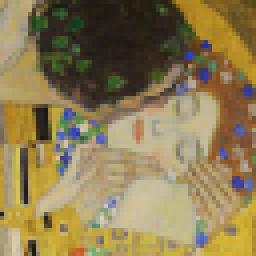

All available painting targets:


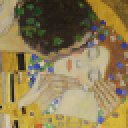

In [7]:
#@title Choose New Target Image
target_img = load_painting(TARGET_PAINTING)
print('New transition target:')
imshow(zoom(to_rgb(target_img), 4), fmt='png')

all_targets = [load_painting(p.stem) for p in AVAILABLE_PAINTINGS]
print('All available painting targets:')
if all_targets:
  imshow(zoom(tile2d([to_rgb(img).numpy() for img in all_targets], w=len(all_targets)), 2), fmt='png')
else:
  print("No painting targets available to display.")


batch rows: old-model/pool input -> transition mid -> transition final


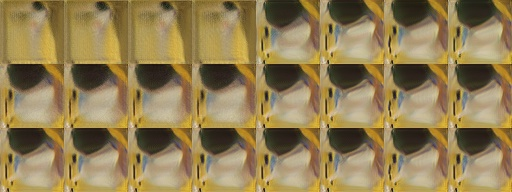

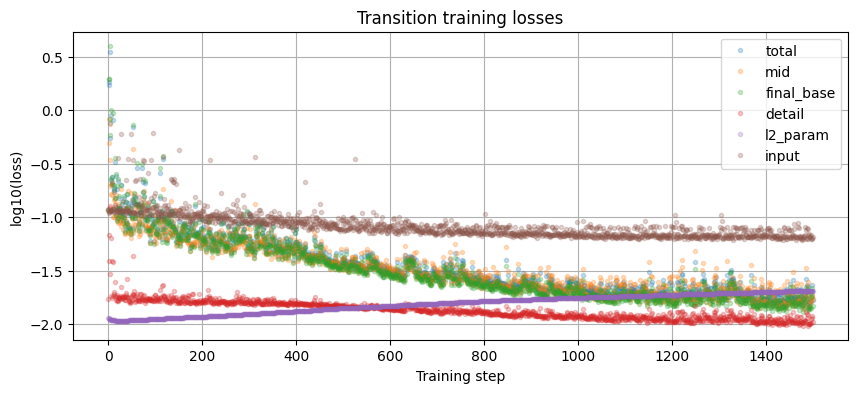

 step: 1500, log10(loss): -1.774, log10(final): -1.834, log10(detail): -1.983
Saved transition model, logs, visuals, and config in: transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool


In [8]:
#@title Train New Transition Model from an Old-Model Pool

def train_transition_from_old_pool(
    painting_name=TARGET_PAINTING,
    old_weights_path=OLD_WEIGHTS_PATH,
    train_steps=NUM_TRANSITION_STEPS):

  print(f'Training NEW transition model for target: {painting_name}')
  print(f'Old/grow checkpoint used only for pool generation: {old_weights_path}')

  old_weights_path = Path(old_weights_path)
  if not old_weights_path.exists():
    raise FileNotFoundError(
        f'Could not find OLD_WEIGHTS_PATH: {old_weights_path}\n'
        'Check the path, upload the .weights.h5 file, or copy it into the runtime.'
    )

  target_img = load_painting(painting_name)

  safe_old_name = old_weights_path.stem.replace('.weights', '')
  log_dir = Path('transition_log') / f'old_{safe_old_name}_to_{painting_name}' / TRANSITION_RUN_NAME
  log_dir.mkdir(parents=True, exist_ok=True)
  for old_file in log_dir.glob('*'):
    old_file.unlink()

  p = TARGET_PADDING
  pad_target = tf.pad(target_img, [(p, p), (p, p), (0, 0)])
  h, w = pad_target.shape[:2]

  seed_np = np.zeros([h, w, CHANNEL_N], np.float32)
  seed_np[h//2, w//2, 3:] = 1.0
  seed_tf_1 = tf.constant(seed_np[None, ...], tf.float32)

  def loss_f(x):
    pred = to_rgba(x)
    diff_rgb = tf.square(pred[..., :3] - pad_target[None, ..., :3])
    diff_a = tf.square(pred[..., 3:4] - pad_target[None, ..., 3:4])
    return tf.reduce_mean(diff_rgb * RGB_W + diff_a * A_W, [-2, -3, -1])

  def gradient_loss_f(x):
    pred = to_rgba(x)
    pred_rgb = pred[..., :3]
    target_rgb = pad_target[None, ..., :3]

    pred_dx = pred_rgb[:, :, 1:, :] - pred_rgb[:, :, :-1, :]
    target_dx = target_rgb[:, :, 1:, :] - target_rgb[:, :, :-1, :]

    pred_dy = pred_rgb[:, 1:, :, :] - pred_rgb[:, :-1, :, :]
    target_dy = target_rgb[:, 1:, :, :] - target_rgb[:, :-1, :, :]

    loss_dx = tf.reduce_mean(tf.square(pred_dx - target_dx), [-2, -3, -1])
    loss_dy = tf.reduce_mean(tf.square(pred_dy - target_dy), [-2, -3, -1])
    return loss_dx + loss_dy

  # Frozen old/grow model. It is not trained.
  old_ca = CAModel()
  old_ca.load_weights(str(old_weights_path))
  old_ca.trainable = False

  # New transition model: random initialization.
  # This is the key difference from fine-tuning.
  ca = CAModel()

  @tf.function
  def make_old_model_batch_tf(batch_n):
    x = tf.repeat(seed_tf_1, batch_n, axis=0)
    old_steps = tf.random.uniform([], OLD_POOL_MIN_STEPS, OLD_POOL_MAX_STEPS, tf.int32)

    for _ in tf.range(old_steps):
      x = old_ca(x, fire_rate=tf.constant(OLD_FIRE_RATE, tf.float32))

    return tf.stop_gradient(x)

  def make_old_model_batch_np(batch_n):
    return make_old_model_batch_tf(tf.constant(batch_n, tf.int32)).numpy()

  def build_initial_old_pool():
    print(f'Building old-model transition pool: {POOL_SIZE} states')
    xs = []
    remaining = POOL_SIZE
    while remaining > 0:
      n = min(OLD_POOL_CHUNK_SIZE, remaining)
      xs.append(make_old_model_batch_np(n))
      remaining -= n
      print(f'\rcreated {POOL_SIZE - remaining}/{POOL_SIZE} pool states', end='')
    print()
    return np.concatenate(xs, axis=0).astype(np.float32)

  pool = SamplePool(x=build_initial_old_pool())

  lr_sched = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
      [LR_DECAY_STEP_1, LR_DECAY_STEP_2],
      [LR, LR * 0.5, LR * 0.2]
  )
  trainer = tf.keras.optimizers.Adam(lr_sched)

  logs = {
      'total': [],
      'mid': [],
      'final_base': [],
      'detail': [],
      'l2_param': [],
      'input': [],
  }

  @tf.function
  def train_step(x0):
    transition_steps = tf.random.uniform([], TRANSITION_STEP_MIN, TRANSITION_STEP_MAX, tf.int32)
    mid_n = transition_steps // 2

    with tf.GradientTape() as g:
      x = x0

      for _ in tf.range(mid_n):
        x = ca(x)

      x_mid = x
      loss_mid = tf.reduce_mean(loss_f(x_mid))

      for _ in tf.range(transition_steps - mid_n):
        x = ca(x)

      x_final = x

      loss_final_base = tf.reduce_mean(loss_f(x_final))
      loss_detail = tf.reduce_mean(gradient_loss_f(x_final))
      l2_param = tf.add_n([tf.reduce_mean(tf.square(w)) for w in ca.trainable_weights])

      loss = (
          W_MID_LOSS * loss_mid
          + W_FINAL_LOSS * (loss_final_base + DETAIL_W * loss_detail)
          + L2_PARAM_W * l2_param
      )

    grads = g.gradient(loss, ca.trainable_weights)
    grads = [grad / (tf.norm(grad) + 1e-8) for grad in grads]
    trainer.apply_gradients(zip(grads, ca.trainable_weights))

    input_loss = tf.reduce_mean(loss_f(x0))

    return x_mid, x_final, loss, loss_mid, loss_final_base, loss_detail, l2_param, input_loss

  # Save the random initialized model for reference.
  export_model(ca, log_dir / '0000_random_init')
  generate_transition_pool_figure(pool, 0, log_dir)

  for i in range(train_steps + 1):
    batch = pool.sample(BATCH_SIZE)
    x0 = batch.x.copy()

    # Replace part of the batch with fresh old-model states.
    # This keeps the transition model connected to the actual old-model source distribution.
    if OLD_INPUT_BATCH_N > 0:
      n_old = min(OLD_INPUT_BATCH_N, BATCH_SIZE)
      x0[:n_old] = make_old_model_batch_np(n_old)

    x_mid, x_final, loss, loss_mid, loss_final_base, loss_detail, l2_param, input_loss = train_step(tf.constant(x0, tf.float32))

    # Commit the student outputs back to the transition pool.
    # This makes the pool progressively contain transition states.
    batch.x[:] = x_final.numpy()
    batch.commit()

    step_i = len(logs['total'])
    logs['total'].append(float(loss.numpy()))
    logs['mid'].append(float(loss_mid.numpy()))
    logs['final_base'].append(float(loss_final_base.numpy()))
    logs['detail'].append(float(loss_detail.numpy()))
    logs['l2_param'].append(float(l2_param.numpy()))
    logs['input'].append(float(input_loss.numpy()))

    # Optional pool refresh: replace a small random subset with new old-model states.
    if REFRESH_POOL_EVERY and step_i > 0 and step_i % REFRESH_POOL_EVERY == 0:
      refresh_n = max(1, int(POOL_SIZE * REFRESH_POOL_FRAC))
      refresh_idx = np.random.choice(POOL_SIZE, refresh_n, replace=False)
      pool.x[refresh_idx] = make_old_model_batch_np(refresh_n)

    if step_i % 10 == 0:
      generate_transition_pool_figure(pool, step_i, log_dir)

    if step_i % VIS_EVERY == 0:
      clear_output()
      visualize_transition_batch(tf.constant(x0, tf.float32), x_mid, x_final, step_i, log_dir)
      plot_transition_losses(logs)

    if step_i % EXPORT_EVERY == 0:
      export_model(ca, log_dir / f'{step_i:04d}')

    print(
      '\r step: %d, log10(loss): %.3f, log10(final): %.3f, log10(detail): %.3f'
      % (
          step_i,
          np.log10(max(logs['total'][-1], 1e-12)),
          np.log10(max(logs['final_base'][-1], 1e-12)),
          np.log10(max(logs['detail'][-1], 1e-12)),
      ),
      end=''
    )

  export_model(ca, log_dir / 'final')

  for key, values in logs.items():
    np.save(log_dir / f'{key}_log.npy', np.asarray(values, dtype=np.float32))

  with open(log_dir / 'transition_config.json', 'w') as f:
    json.dump({
        'painting_name': painting_name,
        'old_weights_path': str(old_weights_path),
        'CHANNEL_N': CHANNEL_N,
        'TARGET_PADDING': TARGET_PADDING,
        'TARGET_SIZE': TARGET_SIZE,
        'BATCH_SIZE': BATCH_SIZE,
        'POOL_SIZE': POOL_SIZE,
        'CELL_FIRE_RATE': CELL_FIRE_RATE,
        'OLD_POOL_MIN_STEPS': OLD_POOL_MIN_STEPS,
        'OLD_POOL_MAX_STEPS': OLD_POOL_MAX_STEPS,
        'OLD_FIRE_RATE': OLD_FIRE_RATE,
        'OLD_INPUT_BATCH_N': OLD_INPUT_BATCH_N,
        'REFRESH_POOL_EVERY': REFRESH_POOL_EVERY,
        'REFRESH_POOL_FRAC': REFRESH_POOL_FRAC,
        'TRANSITION_STEP_MIN': TRANSITION_STEP_MIN,
        'TRANSITION_STEP_MAX': TRANSITION_STEP_MAX,
        'RGB_W': RGB_W,
        'A_W': A_W,
        'DETAIL_W': DETAIL_W,
        'W_MID_LOSS': W_MID_LOSS,
        'W_FINAL_LOSS': W_FINAL_LOSS,
        'L2_PARAM_W': L2_PARAM_W,
        'LR': LR,
    }, f, indent=2)

  print(f'\nSaved transition model, logs, visuals, and config in: {log_dir}')
  return ca, logs, log_dir, old_ca, seed_np


ca, logs, log_dir, old_ca, seed_np = train_transition_from_old_pool()


# Transition Figures


In [9]:
#@title Transition Video: seed -> old model -> new transition model
# This video shows the actual intended use:
# seed grows with the old model, then the new transition model takes over.

OLD_VIDEO_STEPS = 120          #@param {type:"integer"}
TRANSITION_VIDEO_STEPS = 500   #@param {type:"integer"}
VIDEO_FIRE_RATE_OLD = 0.5      #@param {type:"number"}
VIDEO_FIRE_RATE_NEW = 0.5      #@param {type:"number"}
VIDEO_ZOOM = 4                 #@param {type:"integer"}

if 'old_ca' not in globals() or 'ca' not in globals():
  raise ValueError('Run the transition training cell first.')

out_fn = str(log_dir / 'seed_old_to_transition_model.mp4')

x = seed_np[None, ...].astype(np.float32)

with VideoWriter(out_fn) as vid:
  # Phase 1: old model grows from seed.
  for _ in tqdm.trange(OLD_VIDEO_STEPS, desc='old grow phase'):
    vid.add(zoom(to_rgb(x)[0].numpy(), VIDEO_ZOOM))
    x = old_ca(tf.constant(x), fire_rate=tf.constant(VIDEO_FIRE_RATE_OLD, tf.float32)).numpy()

  # Phase 2: new transition model takes over.
  for _ in tqdm.trange(TRANSITION_VIDEO_STEPS, desc='new transition phase'):
    vid.add(zoom(to_rgb(x)[0].numpy(), VIDEO_ZOOM))
    x = ca(tf.constant(x), fire_rate=tf.constant(VIDEO_FIRE_RATE_NEW, tf.float32)).numpy()

print('Saved:', out_fn)
mvp.ipython_display(out_fn)


new transition phase: 100%|██████████| 500/500 [00:03<00:00, 128.37it/s]


Saved: transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool/seed_old_to_transition_model.mp4


In [10]:
#@title Transition Checkpoint Comparison Video
# Compares saved transition checkpoints, all starting from the same old-model grown state.

CHECKPOINT_STEPS = [0, 500, 1000, 2000, 4000, 6000]  #@param
OLD_PREP_STEPS = 120                                 #@param {type:"integer"}
CHECKPOINT_VIDEO_STEPS = 500                         #@param {type:"integer"}
CHECKPOINT_VIDEO_ZOOM = 2                            #@param {type:"integer"}

models = []
loaded_steps = []

for step in CHECKPOINT_STEPS:
  weights_path = log_dir / f'{step:04d}.weights.h5'
  if weights_path.exists():
    ca_step = CAModel()
    ca_step.load_weights(str(weights_path))
    models.append(ca_step)
    loaded_steps.append(step)

final_weights_path = log_dir / 'final.weights.h5'
if final_weights_path.exists():
  ca_final = CAModel()
  ca_final.load_weights(str(final_weights_path))
  models.append(ca_final)
  loaded_steps.append('final')

if not models:
  raise ValueError('No transition checkpoint weights found. Run the transition training cell first.')

# Build a common old-model starting state.
x_start = seed_np[None, ...].astype(np.float32)
for _ in range(OLD_PREP_STEPS):
  x_start = old_ca(tf.constant(x_start), fire_rate=tf.constant(VIDEO_FIRE_RATE_OLD, tf.float32)).numpy()

x = np.repeat(x_start, len(models), axis=0)

out_fn = str(log_dir / 'transition_checkpoint_comparison.mp4')
with VideoWriter(out_fn) as vid:
  for _ in tqdm.trange(CHECKPOINT_VIDEO_STEPS):
    vis = np.hstack(to_rgb(x).numpy())
    vid.add(zoom(vis, CHECKPOINT_VIDEO_ZOOM))
    for model_i, ca_step in enumerate(models):
      x[model_i:model_i+1] = ca_step(tf.constant(x[model_i:model_i+1])).numpy()

print('Loaded checkpoints:', loaded_steps)
print('Saved:', out_fn)
mvp.ipython_display(out_fn)


100%|██████████| 500/500 [00:07<00:00, 64.29it/s]


Loaded checkpoints: [0, 500, 1000, 'final']
Saved: transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool/transition_checkpoint_comparison.mp4


In [11]:
#@title Transition Batch Progress Video
frames = sorted(glob.glob(str(log_dir / 'transition_batch_*.jpg')))
if not frames:
  raise ValueError('No transition_batch_*.jpg frames found. Run the transition training cell first.')

clip_path = str(log_dir / 'transition_batches.mp4')
mvp.ImageSequenceClip(frames, fps=10.0).write_videofile(clip_path)
mvp.ipython_display(clip_path)


Moviepy - Building video transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool/transition_batches.mp4.
Moviepy - Writing video transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool/transition_batches.mp4



Moviepy - Done !
Moviepy - video ready transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool/transition_batches.mp4


In [12]:
#@title Transition Pool Progress Video
frames = sorted(glob.glob(str(log_dir / '*_pool.jpg')))
if not frames:
  raise ValueError('No *_pool.jpg frames found. Run the transition training cell first.')

clip_path = str(log_dir / 'transition_pool.mp4')
mvp.ImageSequenceClip(frames, fps=10.0).write_videofile(clip_path)
mvp.ipython_display(clip_path)


Moviepy - Building video transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool/transition_pool.mp4.
Moviepy - Writing video transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool/transition_pool.mp4



Moviepy - Done !
Moviepy - video ready transition_log/old_1500_to_the_kiss_zoom/transition_from_old_pool/transition_pool.mp4


In [13]:
#@title Zip Transition Log
import shutil
try:
  from google.colab import files
  can_download = True
except Exception:
  can_download = False

zip_base = str(Path('transition_log') / f'{TARGET_PAINTING}_{TRANSITION_RUN_NAME}')
shutil.make_archive(zip_base, 'zip', str(log_dir))
print('Created:', zip_base + '.zip')

if can_download:
  files.download(zip_base + '.zip')


Created: transition_log/the_kiss_zoom_transition_from_old_pool.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>